In [1]:
# Step 1: Import pandas
import pandas as pd

# Step 2: Load CSV from URL
url = 'csv/allign.csv'
df = pd.read_csv(url)

# Step 3: Display the first few rows of the DataFrame
display(df)


,TIME,LABEL
0,120.150204,NaN
1,120.359184,NaN
2,121.018776,NaN
3,121.234286,NaN
4,121.880816,NaN
...,...,...
75,150.142041,NaN
76,150.253061,NaN
77,150.690612,NaN
78,151.010612,NaN


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
import mido

# --- IOI Analysis and Grid Finding Functions ---
# (analyze_iois and evaluate_grid_fit functions remain the same, so they are omitted here for brevity)
# (Just make sure they are in your notebook cell)

def analyze_iois(df, onset_column):
    """Calculates and visualizes IOIs from a DataFrame."""
    if onset_column not in df.columns:
        print(f"Error: Column '{onset_column}' not found. Available columns: {list(df.columns)}")
        return np.array([]), {}
    onset_times = df[onset_column].values
    if len(onset_times) < 2: return np.array([]), {}
    iois = np.diff(onset_times)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('Inter-Onset Interval (IOI) Analysis', fontsize=16)
    ax1.plot(iois, marker='.', linestyle='-', color='teal')
    ax1.set_title('IOI Sequence'); ax1.set_xlabel('Event Number'); ax1.set_ylabel('Interval Duration (s)'); ax1.grid(True, linestyle='--', alpha=0.6)
    ax2.hist(iois, bins=30, color='skyblue', edgecolor='black')
    ax2.set_title('IOI Distribution (Histogram)'); ax2.set_xlabel('Interval Duration (s)'); ax2.set_ylabel('Frequency'); ax2.grid(True, linestyle='--', alpha=0.6)
    stats = {'mean': np.mean(iois), 'std': np.std(iois)}
    stats['cv'] = stats['std'] / stats['mean'] if stats['mean'] != 0 else 0
    ax2.axvline(stats['mean'], color='red', linestyle='--', label=f"Mean: {stats['mean']:.3f}s"); ax2.legend()
    plt.tight_layout(rect=[0, 0, 1, 0.96]); plt.show()
    return iois, stats

# --- (MODIFIED) find_optimal_grid_period Function ---
def find_optimal_grid_period(iois, min_period=0.1, max_period=1.0, num_steps=1000, top_n_to_label=5):
    """
    Searches for optimal grid periods, now with cleaner plotting.

    Args:
        iois (np.ndarray): Array of Inter-Onset Intervals.
        min_period (float): The minimum period to test.
        max_period (float): The maximum period to test.
        num_steps (int): The number of steps in the search range.
        top_n_to_label (int): The number of best candidates to label on the plot.

    Returns:
        tuple: A tuple containing two numpy arrays:
            - candidate_periods (np.ndarray): Array of periods at local minima.
            - candidate_errors (np.ndarray): Array of error values at those minima.
    """
    base_values = np.linspace(min_period, max_period, num_steps)
    errors = np.array([np.sum((iois - v * np.round(iois / v))**2) for v in base_values])
    
    minima_indices, _ = find_peaks(-errors, distance=5)

    if minima_indices.size == 0:
        plt.figure(figsize=(12, 6))
        plt.plot(base_values, errors, label='Quantization Error')
        plt.title('Grid Period Finding - No Local Minima Found')
        plt.show()
        return np.array([]), np.array([])

    # --- Improved Plotting Logic ---
    candidate_periods = base_values[minima_indices]
    candidate_errors = errors[minima_indices]

    # Sort candidates by error to find the best ones
    sorted_indices = np.argsort(candidate_errors)
    best_n_indices = minima_indices[sorted_indices[:top_n_to_label]]
    
    plt.figure(figsize=(12, 7))
    # Plot the main error curve
    plt.plot(base_values, errors, label='Quantization Error', color='royalblue', zorder=1)
    
    # Plot ALL found minima as small red dots
    plt.plot(candidate_periods, candidate_errors, 'o', color='red', markersize=5, label='All Local Minima', zorder=2)

    # Highlight the single BEST minimum with a prominent star
    best_idx = minima_indices[sorted_indices[0]]
    plt.plot(base_values[best_idx], errors[best_idx], '*', color='gold', markersize=15, markeredgecolor='black', label='Best Candidate', zorder=4)

    # Add text labels for only the TOP N candidates
    for idx in best_n_indices:
        plt.text(base_values[idx] + 0.005, errors[idx], f'{base_values[idx]:.3f}s', color='black', zorder=3,
                 bbox=dict(facecolor='white', alpha=0.5, edgecolor='none', boxstyle='round,pad=0.2'))

    plt.title('Grid Period Finding by Error Minimization')
    plt.xlabel('Candidate Grid Period (s)')
    plt.ylabel('Error (Sum of Squared Residuals)')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.show()
    
    return candidate_periods, candidate_errors

# --- Make sure your other functions (analyze_iois, evaluate_grid_fit) are also in this cell ---

# --- (REVISED) evaluate_grid_fit Function ---
# This is the new version. Replace the old function with this one.

def evaluate_grid_fit(iois, base_period):
    """
    Evaluates and visualizes how well a given grid period fits the IOI data.
    NOW INCLUDES calculation and display of timing bias (mean/median residual).
    """
    # --- Existing logic (no changes here) ---
    multipliers = np.round(iois / base_period)
    reconstructed_iois = base_period * multipliers
    residuals = iois - reconstructed_iois
    df_results = pd.DataFrame({
        'Original_IOI': iois,
        'Multiplier': multipliers.astype(int),
        'Reconstructed_IOI': reconstructed_iois,
        'Residual': residuals
    })

    # =========================================================================
    # --- NEW: Calculate and display residual statistics ---
    # =========================================================================
    mean_residual_s = df_results['Residual'].mean()
    median_residual_s = df_results['Residual'].median()
    std_dev_s = df_results['Residual'].std()

    # Convert to milliseconds for easier interpretation
    mean_residual_ms = mean_residual_s * 1000
    median_residual_ms = median_residual_s * 1000

    print("\n--- Timing Deviation (Residual) Analysis ---")
    print(f"Mean Residual:   {mean_residual_ms:+.2f} ms")
    print(f"Median Residual: {median_residual_ms:+.2f} ms")
    print(f"Std. Deviation:  {std_dev_s * 1000:.2f} ms (Jitter)")

    # Provide a human-readable interpretation
    if abs(mean_residual_ms) < 5: # A small threshold for "on the grid"
        print("Interpretation: The timing is very close to the grid model (low bias).")
    elif mean_residual_ms > 0:
        print("Interpretation: On average, the events are played LATE compared to the grid (dragging).")
    else:
        print("Interpretation: On average, the events are played EARLY compared to the grid (rushing).")
    print("--------------------------------------------")
    # =========================================================================

    # --- Plotting logic (with one addition) ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f'Evaluation of Grid Fit for Period = {base_period:.3f}s', fontsize=16)

    ax1.plot(df_results['Original_IOI'], 'o-', label='Original IOIs', color='teal', alpha=0.8)
    ax1.plot(df_results['Reconstructed_IOI'], 'x--', label='Reconstructed Grid', color='coral', markersize=8)
    ax1.set_title('Original vs. Reconstructed IOIs'); ax1.set_xlabel('Event Number'); ax1.set_ylabel('IOI Duration (s)'); ax1.legend(); ax1.grid(True, linestyle='--', alpha=0.6)

    ax2.hist(df_results['Residual'], bins=20, color='lightcoral', edgecolor='black')
    ax2.axvline(0, color='black', linestyle='-', label='Perfect Grid Alignment')

    # --- NEW: Add a line for the mean residual on the plot ---
    ax2.axvline(mean_residual_s, color='blue', linestyle='--', label=f'Mean Dev: {mean_residual_ms:+.1f}ms')

    ax2.set_title('Distribution of Residuals (Timing Deviations)'); ax2.set_xlabel('Residual Duration (s)'); ax2.set_ylabel('Frequency'); ax2.legend(); ax2.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout(rect=[0, 0, 1, 0.96]);
    plt.show()

    return df_results

--- Step 1: Initial IOI Analysis ---


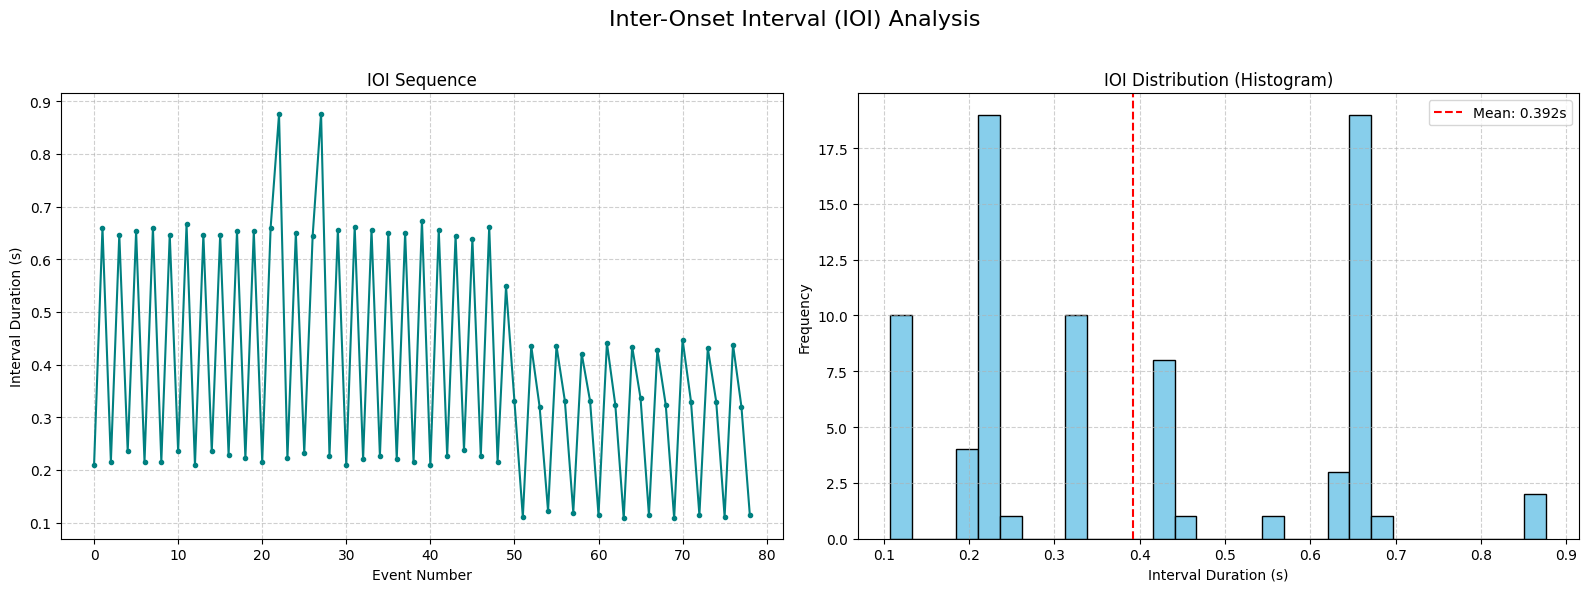


--- Step 2: Searching for Optimal Grid Period (Range: 0.1s - 0.5s) ---


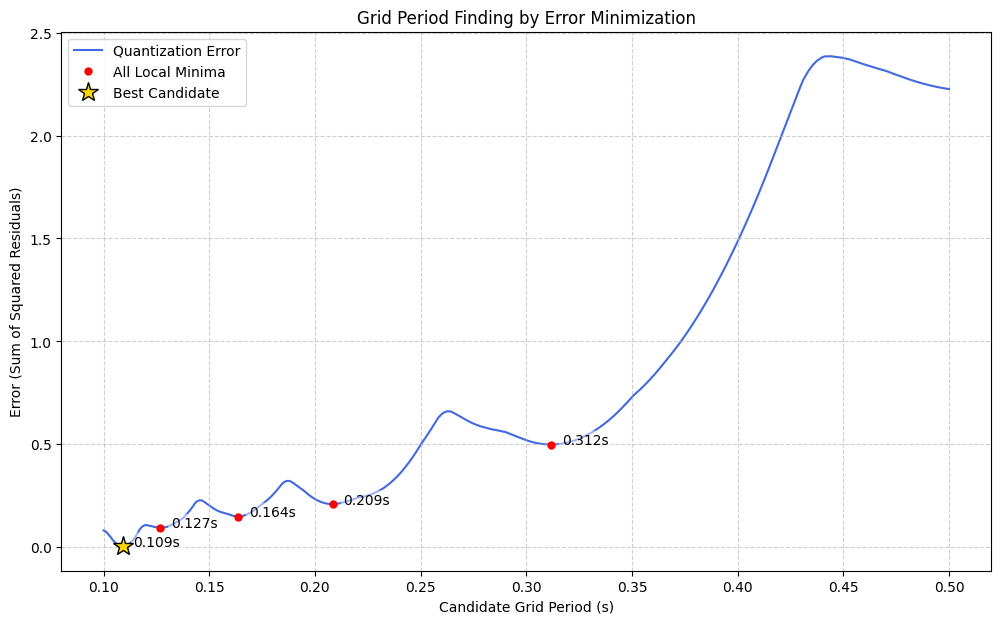


Top 5 potential grid period(s) (sorted by error):
  - Period: 0.1092 s,  Error (Loss): 0.0049  <-- Best
  - Period: 0.1268 s,  Error (Loss): 0.0947
  - Period: 0.1637 s,  Error (Loss): 0.1492
  - Period: 0.2085 s,  Error (Loss): 0.2094
  - Period: 0.3118 s,  Error (Loss): 0.4990
---------------------------------------------

--- Step 3: Evaluating the Chosen Candidate Grid ---
Automatically evaluating best-fit period: 0.1092 s

--- Timing Deviation (Residual) Analysis ---
Mean Residual:   +0.87 ms
Median Residual: +1.09 ms
Std. Deviation:  7.88 ms (Jitter)
Interpretation: The timing is very close to the grid model (low bias).
--------------------------------------------


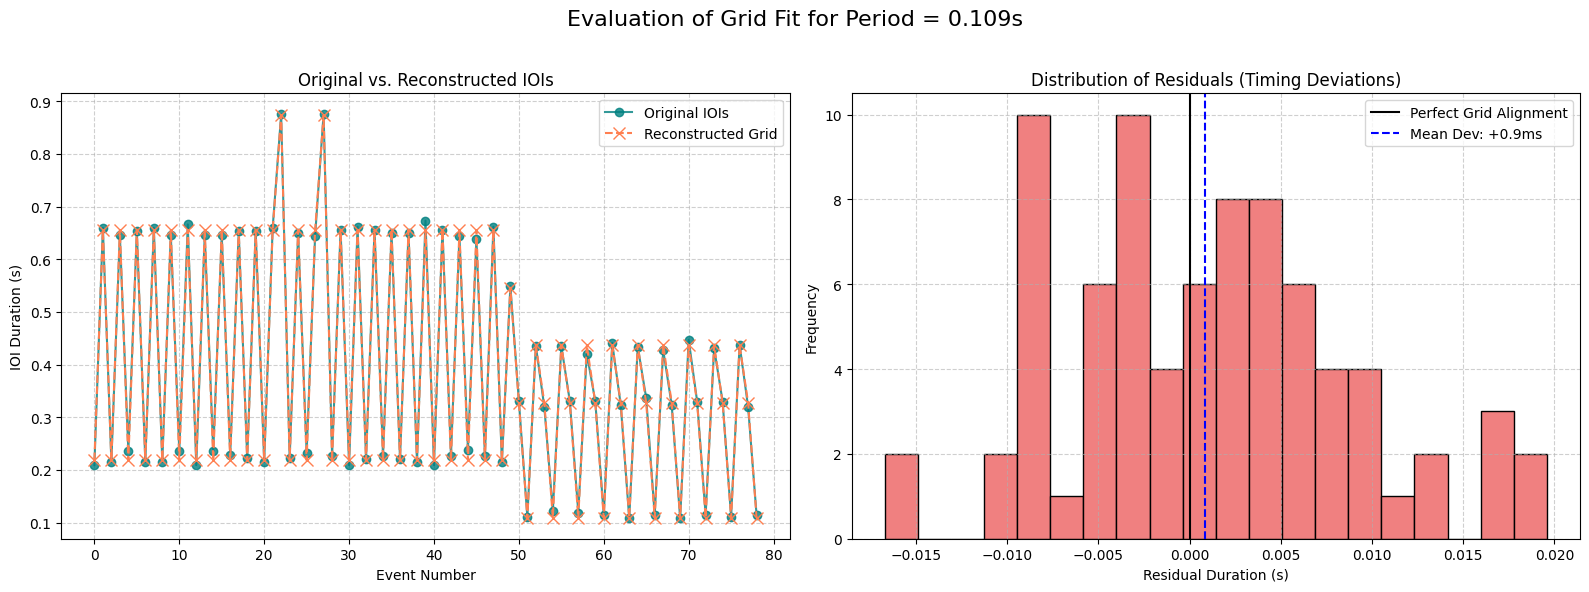


Displaying full Analysis Results Table:


,Original_IOI,Multiplier,Reconstructed_IOI,Residual
0,0.208980,2,0.218418,-0.009439
1,0.659592,6,0.655255,0.004337
2,0.215510,2,0.218418,-0.002908
3,0.646531,6,0.655255,-0.008725
4,0.235102,2,0.218418,0.016684
...,...,...,...,...
74,0.329796,3,0.327628,0.002168
75,0.111020,1,0.109209,0.001811
76,0.437551,4,0.436837,0.000714
77,0.320000,3,0.327628,-0.007628


In [6]:
# ===================================================================
#                          CONFIGURATION
# ===================================================================

# --- Data Configuration ---
ONSET_COLUMN_NAME = 'TIME'

# --- Grid Search Configuration ---
MIN_GRID_PERIOD_S = 0.1
MAX_GRID_PERIOD_S = 0.5
TOP_N_CANDIDATES = 5 # How many of the best candidates to show in the list and plot

# --- Evaluation Configuration ---
# To manually select a period, set this to a number (e.g., 0.247).
# To use the automatic best-fit, set this to None.
MANUAL_GRID_PERIOD_S = None # <-- SET A VALUE HERE TO OVERRIDE

# --- Results Display Configuration ---
SHOW_FULL_RESULTS_DF = True

# ===================================================================
#                         ANALYSIS WORKFLOW
# ===================================================================

if 'df' in locals() and isinstance(df, pd.DataFrame):
    
    # --- Step 1: Perform Initial IOI Analysis ---
    print("--- Step 1: Initial IOI Analysis ---")
    iois, ioi_stats = analyze_iois(df, onset_column=ONSET_COLUMN_NAME)

    if iois.size > 0:
        # --- Step 2: Find Candidate Grid Periods ---
        print(f"\n--- Step 2: Searching for Optimal Grid Period (Range: {MIN_GRID_PERIOD_S}s - {MAX_GRID_PERIOD_S}s) ---")
        candidate_periods, candidate_errors = find_optimal_grid_period(
            iois, 
            min_period=MIN_GRID_PERIOD_S, 
            max_period=MAX_GRID_PERIOD_S,
            top_n_to_label=TOP_N_CANDIDATES
        )
        
        if candidate_periods.size > 0:
            # Create a sorted list of candidates
            sorted_candidates = sorted(zip(candidate_periods, candidate_errors), key=lambda item: item[1])
            
            print(f"\nTop {min(TOP_N_CANDIDATES, len(sorted_candidates))} potential grid period(s) (sorted by error):")
            for i, (period, error) in enumerate(sorted_candidates[:TOP_N_CANDIDATES]):
                marker = "  <-- Best" if i == 0 else ""
                print(f"  - Period: {period:.4f} s,  Error (Loss): {error:.4f}{marker}")
            print("-" * 45 + "\n")

            # --- Step 3: Evaluate the Chosen Candidate ---
            print("--- Step 3: Evaluating the Chosen Candidate Grid ---")
            
            # Decide whether to use manual or automatic period
            if MANUAL_GRID_PERIOD_S is not None:
                chosen_period = MANUAL_GRID_PERIOD_S
                print(f"Manually evaluating user-specified period: {chosen_period:.4f} s")
            else:
                # Automatically select the best candidate (the first in the sorted list)
                chosen_period = sorted_candidates[0][0]
                print(f"Automatically evaluating best-fit period: {chosen_period:.4f} s")
            
            results_df = evaluate_grid_fit(iois, chosen_period)
            
            # Display results table based on configuration
            if SHOW_FULL_RESULTS_DF:
                print("\nDisplaying full Analysis Results Table:")
                try: display(results_df)
                except NameError: print(results_df.to_string())
            else:
                print("\nAnalysis Results Table (first 5 rows):")
                try: display(results_df.head())
                except NameError: print(results_df.head())
        else:
            print("\nCould not find any distinct grid periods in the specified range.")
else:
    print("\nERROR: DataFrame 'df' not found. Please run the data loading cell before this.")

Analyzing 79 timing residuals...

--- Method 1: Residuals vs. Event Number ---


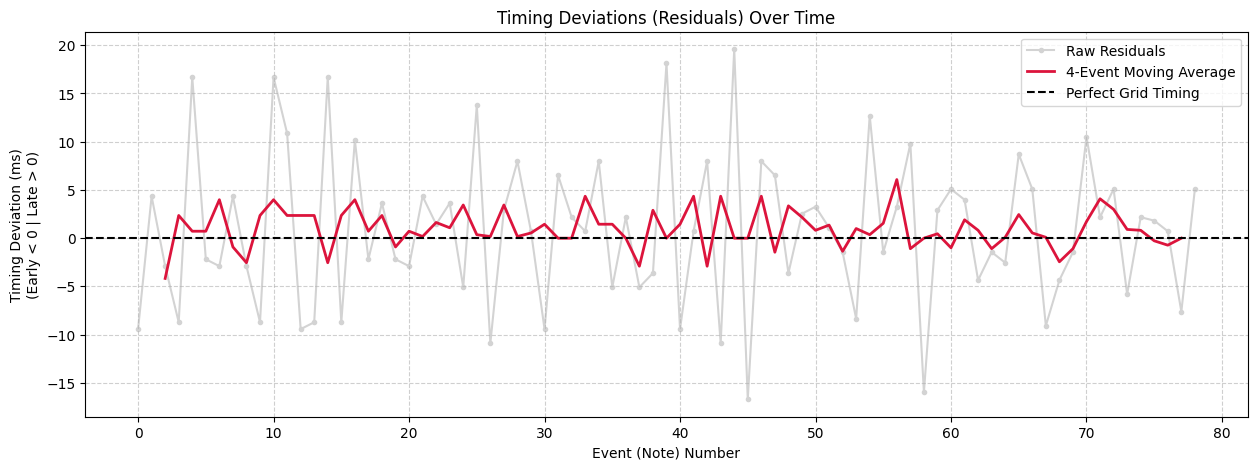

  > What to look for: Is there a general drift up (getting later) or down (getting earlier)?
  > Are there clear, repeating wave-like patterns in the red line?

--- Method 2: Autocorrelation of Residuals ---


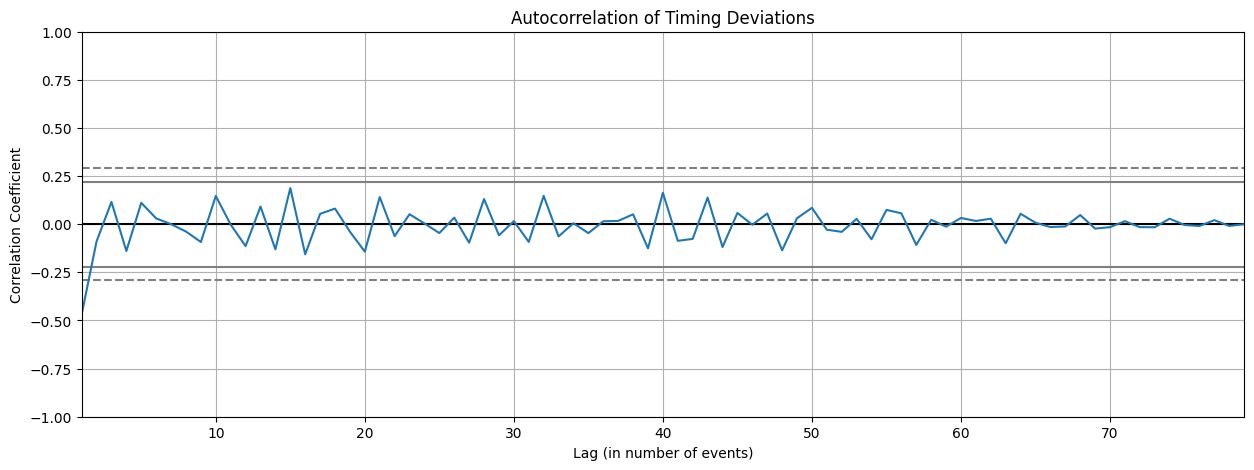

  > What to look for: Significant peaks at non-zero lags.
  > A strong peak at lag=2 means events are played in an alternating pattern (e.g., early-late-early-late).
  > A peak at lag=4 could indicate a repeating 4-beat pattern (common in 4/4 time).

--- Method 3: Self-Similarity Matrix ---


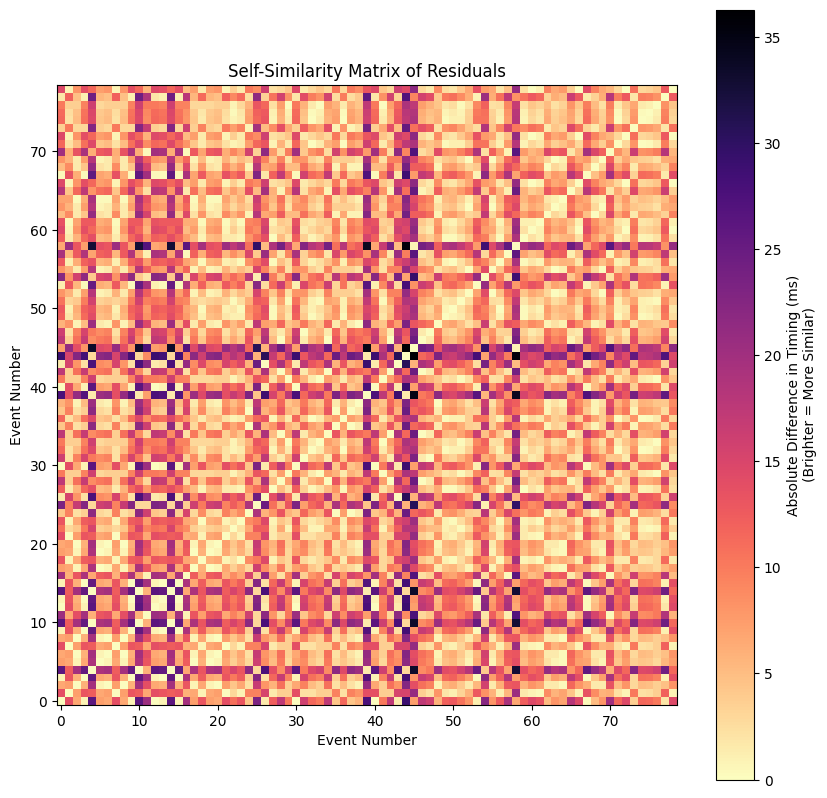

  > What to look for: Lines and checkerboard patterns.
  > The main diagonal is always bright (an event is always similar to itself).
  > BRIGHT LINES PARALLEL to the main diagonal indicate a repeating pattern.
    - If a bright line is at an offset of 4, the pattern repeats every 4 events.
  > CHECKERBOARD patterns indicate alternating structures (like swing rhythm).


In [7]:
# ===================================================================
#           CELL 4: RESIDUAL PATTERN ANALYSIS
# This cell analyzes the sequence of timing deviations to find
# recurring patterns, drift, or rhythmic swing.
# It requires 'results_df' to be created by the main analysis cell.
# ===================================================================
import numpy as np
import matplotlib.pyplot as plt
from pandas.plotting import autocorrelation_plot

# --- Pre-computation Check ---
if 'results_df' not in locals() or results_df.empty:
    print("CRITICAL ERROR: DataFrame 'results_df' not found or is empty.")
    print("Please run the main analysis cell successfully before running this one.")
else:
    # Extract the residual series in milliseconds for easier interpretation
    residuals_ms = results_df['Residual'].values * 1000
    print(f"Analyzing {len(residuals_ms)} timing residuals...")

    # --- METHOD 1: Plotting Residuals Over Time ---
    # This is the most direct way to see trends or simple oscillations.
    print("\n--- Method 1: Residuals vs. Event Number ---")
    plt.figure(figsize=(15, 5))
    
    # Plot the raw residuals
    plt.plot(residuals_ms, 'o-', color='lightgray', markersize=3, label='Raw Residuals', zorder=1)
    
    # Plot a smoothed moving average to highlight the main trend
    # A window of ~8-16 is often good for musical data.
    moving_avg_window = 4
    smoothed_residuals = results_df['Residual'].rolling(window=moving_avg_window, center=True).mean() * 1000
    plt.plot(smoothed_residuals, color='crimson', linewidth=2, label=f'{moving_avg_window}-Event Moving Average', zorder=2)
    
    plt.axhline(0, color='black', linestyle='--', linewidth=1.5, label='Perfect Grid Timing')
    plt.title('Timing Deviations (Residuals) Over Time')
    plt.xlabel('Event (Note) Number')
    plt.ylabel('Timing Deviation (ms)\n(Early < 0 | Late > 0)')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.show()
    print("  > What to look for: Is there a general drift up (getting later) or down (getting earlier)?")
    print("  > Are there clear, repeating wave-like patterns in the red line?")


    # --- METHOD 2: Autocorrelation Plot ---
    # This numerically finds how well the sequence correlates with itself at different lags.
    # It's excellent for finding the *period* of a repeating pattern.
    print("\n--- Method 2: Autocorrelation of Residuals ---")
    plt.figure(figsize=(15, 5))
    autocorrelation_plot(residuals_ms)
    plt.title('Autocorrelation of Timing Deviations')
    plt.xlabel('Lag (in number of events)')
    plt.ylabel('Correlation Coefficient')
    plt.show()
    print("  > What to look for: Significant peaks at non-zero lags.")
    print("  > A strong peak at lag=2 means events are played in an alternating pattern (e.g., early-late-early-late).")
    print("  > A peak at lag=4 could indicate a repeating 4-beat pattern (common in 4/4 time).")


    # --- METHOD 3: Self-Similarity Matrix (SSM) ---
    # This is a powerful visualization of the pattern structure.
    print("\n--- Method 3: Self-Similarity Matrix ---")
    
    # Create the matrix: ssm[i, j] will store the absolute difference between residual[i] and residual[j]
    # We use numpy broadcasting for a fast calculation instead of slow Python loops.
    residuals_col = residuals_ms[:, np.newaxis] # Shape (N, 1)
    residuals_row = residuals_ms[np.newaxis, :] # Shape (1, N)
    ssm = np.abs(residuals_col - residuals_row)

    plt.figure(figsize=(10, 10))
    # We use a reversed colormap ('magma_r') so that low differences (high similarity) are bright.
    plt.imshow(ssm, cmap='magma_r', interpolation='nearest', origin='lower')
    plt.title('Self-Similarity Matrix of Residuals')
    plt.xlabel('Event Number')
    plt.ylabel('Event Number')
    cbar = plt.colorbar()
    cbar.set_label('Absolute Difference in Timing (ms)\n(Brighter = More Similar)')
    plt.show()
    print("  > What to look for: Lines and checkerboard patterns.")
    print("  > The main diagonal is always bright (an event is always similar to itself).")
    print("  > BRIGHT LINES PARALLEL to the main diagonal indicate a repeating pattern.")
    print("    - If a bright line is at an offset of 4, the pattern repeats every 4 events.")
    print("  > CHECKERBOARD patterns indicate alternating structures (like swing rhythm).")